In [1]:
!pip install nltk scikit-learn

In [4]:
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [5]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [7]:
from google.colab import files
uploaded = files.upload()

Saving IMDB_Dataset.csv to IMDB_Dataset.csv


In [9]:
import pandas as pd

df = pd.read_csv("IMDB_Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [12]:
print(df.shape)
print(df.columns)
print(df['sentiment'].value_counts())

(50000, 2)
Index(['review', 'sentiment'], dtype='object')
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [14]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    # 1. Lowercase
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+', '', text)

    # 3. Remove special characters & numbers
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # 4. Tokenization
    words = text.split()

    # 5. Remove stopwords + Lemmatization
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

In [15]:
df['clean_text'] = df['review'].apply(preprocess)
df[['review', 'clean_text']].head()

,review,clean_text
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text'])
y = df['sentiment']

In [18]:
print(X.shape)

(50000, 5000)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

models = {
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier()
}

results = {}

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label='positive'),
        "Recall": recall_score(y_test, y_pred, pos_label='positive'),
        "F1 Score": f1_score(y_test, y_pred, pos_label='positive')
    }

In [26]:
for model, metrics in results.items():
    print(f"\n{model}")
    for key, value in metrics.items():
        print(f"{key}: {value:.4f}")


Logistic Regression
Accuracy: 0.8883
Precision: 0.8793
Recall: 0.9022
F1 Score: 0.8906

Naive Bayes
Accuracy: 0.8561
Precision: 0.8528
Recall: 0.8635
F1 Score: 0.8581

Decision Tree
Accuracy: 0.7137
Precision: 0.7168
Recall: 0.7138
F1 Score: 0.7153


Conclusion:

- TF-IDF improved text representation
- Logistic Regression performed best
- Naive Bayes was fast but slightly less accurate
- Decision Tree showed overfitting

Final best model: Logistic Regression

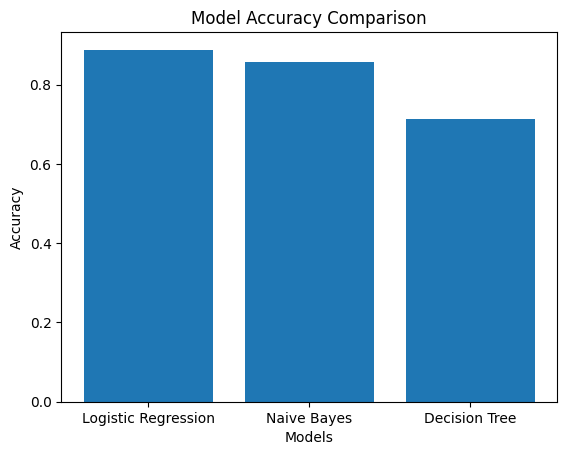

In [27]:
import matplotlib.pyplot as plt

models = list(results.keys())
accuracy = [results[m]["Accuracy"] for m in models]

plt.figure()
plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

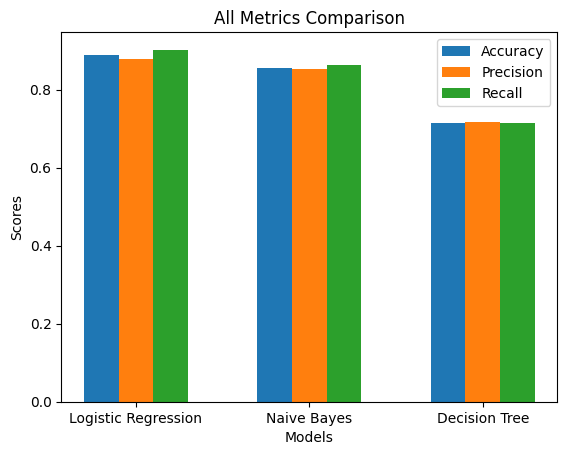

In [29]:
import numpy as np

x = np.arange(len(models))
width = 0.2

plt.figure()
plt.bar(x - width, accuracy, width, label='Accuracy')
plt.bar(x, precision, width, label='Precision')
plt.bar(x + width, recall, width, label='Recall')

plt.xticks(x, models)
plt.title("All Metrics Comparison")
plt.xlabel("Models")
plt.ylabel("Scores")
plt.legend()

plt.show()